# 0. 导入库

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 数据初始化与维度变化

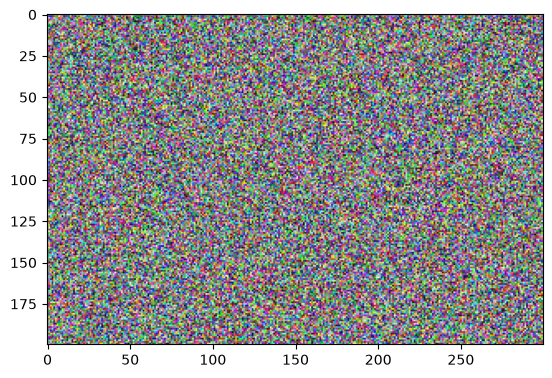

In [98]:
# 这是题目要求的生成法，但是 RGB 类型为整数，会出现一点问题
# grayscale_image = np.random.randint(0, 256, size=(200, 300))
# color_image = np.stack([grayscale_image]*3, axis=-1)

# 这是改成浮点数的生成法，但是黑白的有的难体现出滤镜的效果
# grayscale_image = np.random.rand(200, 300)
# color_image = np.stack([grayscale_image]*3, axis=-1)

# 彩色的
color_image = np.random.rand(200, 300, 3)
plt.imshow(color_image)


# 2. 基于矩阵乘法的滤镜实现

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.014199842980432099..1.3413814392783967].


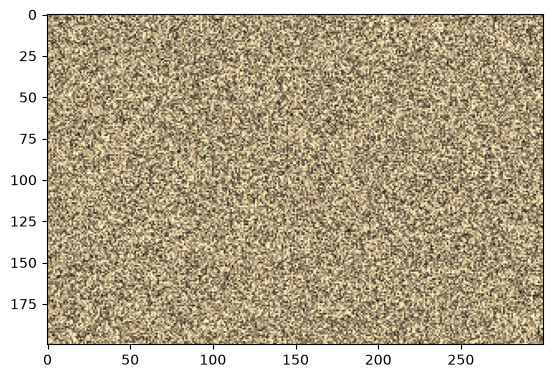

In [59]:
sepia_matrix = np.array([
    [0.393, 0.769, 0.189],
    [0.349, 0.686, 0.168],
    [0.272, 0.534, 0.131]
])

sepia_image = np.clip(color_image @ sepia_matrix.T, 0, 255)
plt.imshow(sepia_image)

# 3. 基于元素级运算的色彩增强

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..85.18386651572625].


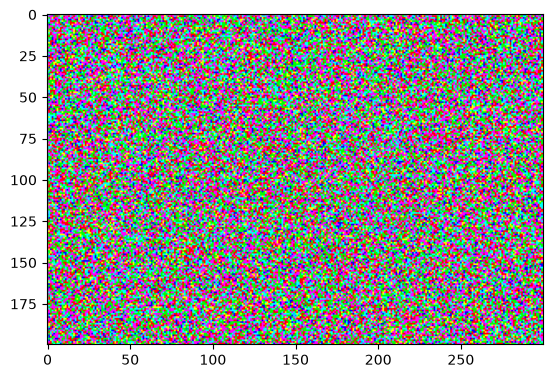

In [61]:
Luminance = 0.299*color_image[...,0] + 0.587*color_image[...,1] + 0.114*color_image[...,2]
Luminance = Luminance[..., np.newaxis]
alpha = 100
new_color_image = np.clip(Luminance + alpha*(color_image - Luminance), 0, 255)
plt.imshow(new_color_image)


# 4. 利用数组切片添加特效

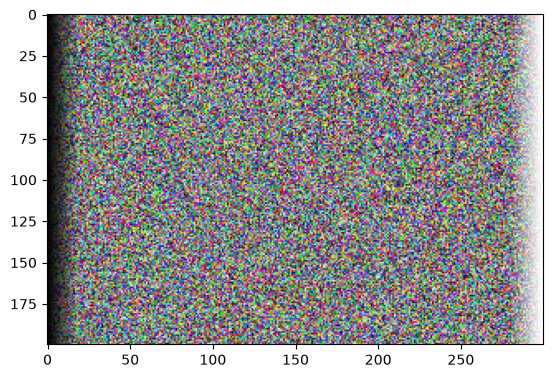

In [99]:
img_with_border = color_image

left_matrix = np.linspace(0, 1, 20)
left_matrix = left_matrix[np.newaxis, :, np.newaxis]
# 写入左边切片
img_with_border[:, :20, :] = img_with_border[:, :20, :] * left_matrix
img_with_border[:, -20:, :] = np.clip(img_with_border[:, -20:, :] + (1-img_with_border[:, -20:, :])*left_matrix, 0, 255)

plt.imshow(img_with_border)
